In [2]:
pip install datasets

   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/559.1 kB ? eta -:--:--
   ---------------------------------------- 559.1/559.1 kB 2.7 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   -------------------- ------------------- 2/4 [multiprocess]
   -------------------- ------------------- 2/4 [multiprocess]
   -------------------- ------------------- 2/4


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Shape: (25000, 2)
Columns: ['text', 'label']

First 5 rows:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

C:\Users\dyash\AppData\Local\Temp\ipykernel_13424\3155508269.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


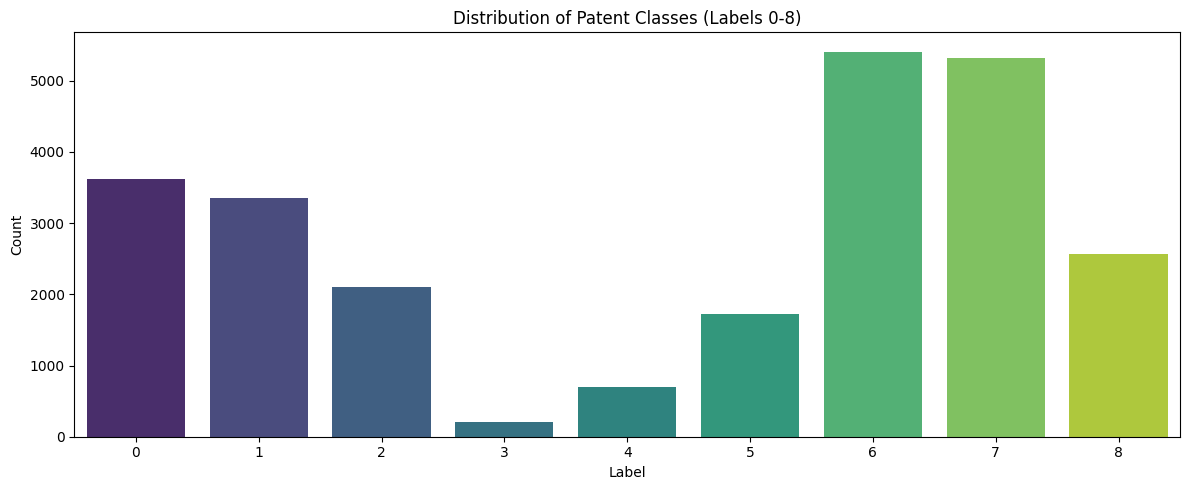

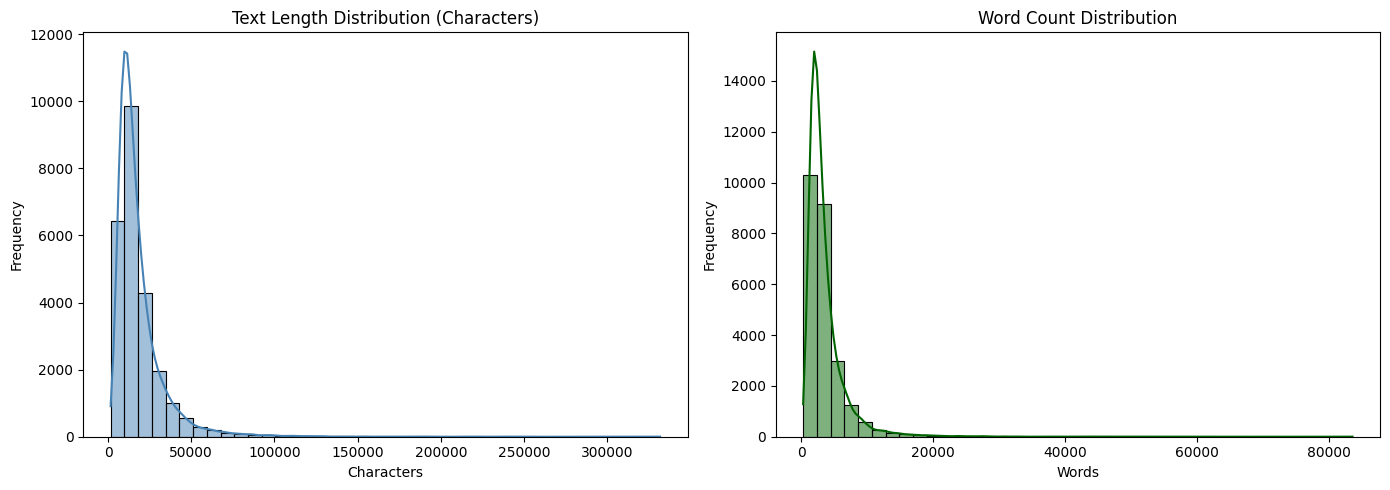


Summary by label:
 label  samples  avg_chars  avg_words  min_chars  max_chars
     0     3614   18801.39    3591.22       1551     240047
     1     3357   14744.60    2802.41       1595     116747
     2     2099   26053.95    5456.53       2381     331797
     3      204   14444.67    2761.68       1991      58044
     4      705   15113.40    2871.94       2260     113225
     5     1730   14249.69    2696.36       2383      81164
     6     5408   20887.68    3952.11       2769     280633
     7     5321   18408.45    3490.18       1705     328957
     8     2562   17257.05    3295.44       2106     194287

Longest abstract length: 331797
Shortest abstract length: 1551
Average abstract length: 18620.45
Median abstract length: 14114.5

Sample texts by label:
Label 0: deployment mechanisms that are configured for use with multi - functional surgical instruments that are operable in bipolar and / or monopolar modes of operation may prove useful i...
Label 1: in accordance with the pr

In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data if it is not already in memory
if 'df' not in globals():
    df = pd.read_parquet('../DATASET.parquet')
else:
    df = ds.copy()

# Basic metadata
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('\nFirst 5 rows:')
print(df.head().to_string(index=False))
print('\nMissing values:')
print(df.isna().sum())
print('\nDtypes:')
print(df.dtypes)

# Add derived text statistics
if 'text' in df.columns:
    df['text_length'] = df['text'].astype(str).str.len()
    df['word_count'] = df['text'].astype(str).str.split().str.len()

# Label distribution
label_counts = df['label'].value_counts().sort_index()
print('\nLabel counts:')
print(label_counts.to_string())

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distribution of Patent Classes (Labels 0-8)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['text_length'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Text Length Distribution (Characters)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

sns.histplot(df['word_count'], bins=40, kde=True, ax=axes[1], color='darkgreen')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Summary statistics by label
summary = df.groupby('label').agg(
    samples=('text', 'size'),
    avg_chars=('text_length', 'mean'),
    avg_words=('word_count', 'mean'),
    min_chars=('text_length', 'min'),
    max_chars=('text_length', 'max')
).reset_index()
print('\nSummary by label:')
print(summary.round(2).to_string(index=False))

# Longest and shortest texts
print('\nLongest abstract length:', df['text_length'].max())
print('Shortest abstract length:', df['text_length'].min())
print('Average abstract length:', round(df['text_length'].mean(), 2))
print('Median abstract length:', df['text_length'].median())

# A few sample texts by label
print('\nSample texts by label:')
for label in sorted(df['label'].unique()):
    sample = df[df['label'] == label]['text'].iloc[0]
    preview = sample[:180].replace('\n', ' ')
    print(f'Label {label}: {preview}...')


Number of samples in the dataset: 25000
